/kaggle/input/competitions/rossmann-store-sales/sample_submission.csv
/kaggle/input/competitions/rossmann-store-sales/store.csv
/kaggle/input/competitions/rossmann-store-sales/train.csv
/kaggle/input/competitions/rossmann-store-sales/test.csv
Promo  Promo2Running
0      False            0.471711
1      False            0.378502
0      True             0.081974
1      True             0.067813
Name: proportion, dtype: float64


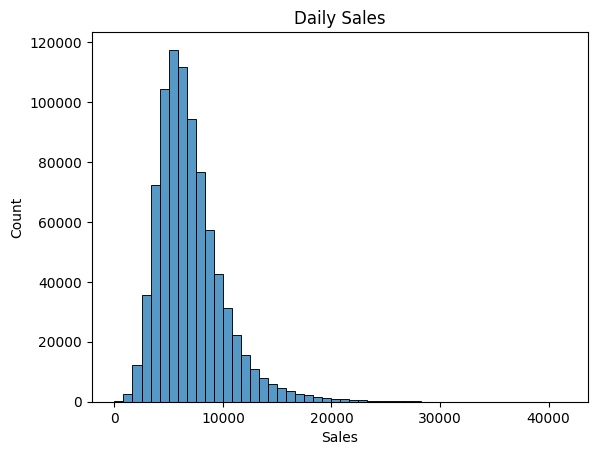

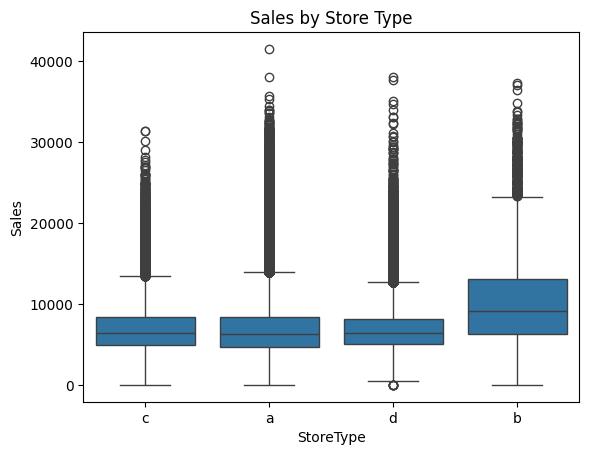

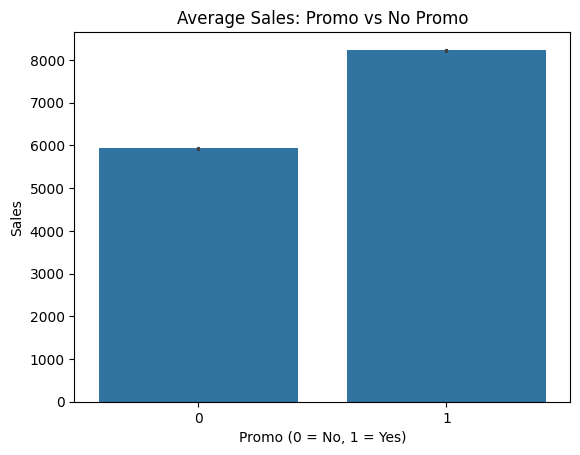

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
train = pd.read_csv('/kaggle/input/competitions/rossmann-store-sales/train.csv', dtype={'StateHoliday':str})
store = pd.read_csv('/kaggle/input/competitions/rossmann-store-sales/store.csv')

store['Promo2'].value_counts()
missing_promo2 = store[store['Promo2SinceWeek'].isna()]
missing_promo2['Promo2'].value_counts()
#all Promo2Since... NaN values are for stores where Promo2 is not running

train_store = train.merge(store, on='Store', how='left')
train_st = train_store[(train_store['Open']==1) & (train_store['StateHoliday']=='0')].copy()
train_st=train_st.dropna(subset=['CompetitionDistance'])
train_st.shape
train_st[['Store','StoreType']].isna().sum()

train_st['Date'] = pd.to_datetime(train_st['Date'])
train_st['MonthAbbr'] = train_st['Date'].dt.strftime('%b')

unique_combos = train_st[['MonthAbbr', 'PromoInterval']].drop_duplicates()
unique_combos['is_promo2_month'] = unique_combos.apply(
    lambda row: row['MonthAbbr'] in str(row['PromoInterval']), axis=1
)

train_st = train_st.merge(unique_combos, on=['MonthAbbr', 'PromoInterval'], how='left')

train_st['Promo2year']=train_st['Date'].dt.year
train_st['Promo2week']=train_st['Date'].dt.isocalendar().week

train_st['Promo2YearWeek'] = train_st['Promo2year'] * 100 + train_st['Promo2week']
train_st['Promo2SinceYearWeek'] = train_st['Promo2SinceYear'] * 100 + train_st['Promo2SinceWeek']
train_st['Promo2Running'] = (train_st['Promo2']==1) & (train_st['is_promo2_month']) & (train_st['Promo2YearWeek'] >= train_st['Promo2SinceYearWeek'])
train_st = train_st.drop(columns=['MonthAbbr', 'is_promo2_month', 'Promo2year', 'Promo2week', 'Promo2YearWeek', 'Promo2SinceYearWeek'])

print(train_st[['Promo','Promo2Running']].value_counts(normalize=True))

sns.histplot(train_st['Sales'], bins=50)
plt.title('Daily Sales')
plt.show()

sns.boxplot(x='StoreType', y='Sales', data=train_st)
plt.title('Sales by Store Type')
plt.show()

sns.barplot(x='Promo', y='Sales', data=train_st)
plt.title('Average Sales: Promo vs No Promo')
plt.xlabel('Promo (0 = No, 1 = Yes)')
plt.show()

#EDA Summary
#Promo - 44% of the time, Promo2 - 15% of the time
#Daily Sales - right skewed, cluster between 5k - 7k 
#Store b higher median than others 
#Promo v NonPromo - 8200 vs 5900


In [3]:
train_st.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Promo2Running
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,False
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",True
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",True
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,False
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,False


In [21]:
#H0 - mean sales promo days = non promo days
from scipy.stats import ttest_ind

promo_sales = train_st[train_st['Promo']==1]['Sales']
n_promo_sales = train_st[train_st['Promo']==0]['Sales']
t_stat, p_val = ttest_ind(promo_sales,n_promo_sales)
print(t_stat)
print(p_val)
#H0 is rejected as p_val = 0


364.09479559750014
0.0


In [5]:
train_st['CompetitionDistance_Standardized'] = (train_st['CompetitionDistance'] - train_st['CompetitionDistance'].mean()) / train_st['CompetitionDistance'].std()
Var = train_st[['DayOfWeek','Promo','StoreType','CompetitionDistance_Standardized','Promo2Running','Assortment']]
Var = pd.get_dummies(Var, columns=['DayOfWeek','StoreType','Assortment'], drop_first=True)
#print(Var.columns.tolist())

import statsmodels.api as sm

Y=train_st['Sales']
X=sm.add_constant(Var).astype(int)

s_model = sm.OLS(Y,X).fit()
print(s_model.summary())
#Promo has strong coef, store b and assortment b strong + and - effect respectively 


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                 1.574e+04
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:06:28   Log-Likelihood:            -7.8590e+06
No. Observations:              841299   AIC:                         1.572e+07
Df Residuals:                  841284   BIC:                         1.572e+07
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [6]:
train_st.groupby(['StoreType','Assortment','Promo'])['Sales'].mean()
# Type B has the smallest relative promo lift (18%) and highest baseline sales
# Assortment b weaker promotional response (7% lift) than Assortment a or c (36-43% lift) for all store types


StoreType  Assortment  Promo
a          a           0         5419.459287
                       1         7914.047728
           c           0         6473.949929
                       1         8980.455161
b          a           0         9979.023661
                       1        12915.963689
           b           0         8318.630037
                       1         8929.774523
           c           0        16643.978761
                       1        20062.815864
c          a           0         5916.880814
                       1         7962.301036
           c           0         6148.030301
                       1         8128.300590
d          a           0         5431.750366
                       1         7686.395986
           c           0         6102.322095
                       1         8207.035546
Name: Sales, dtype: float64

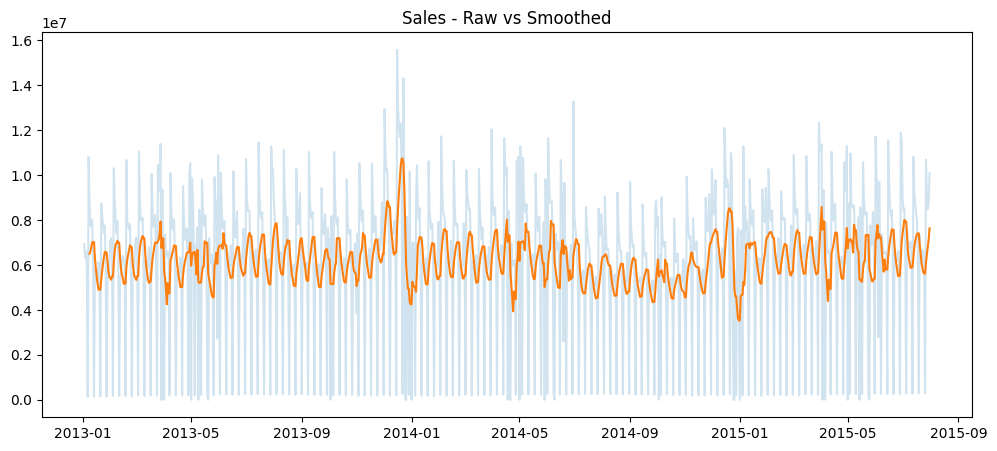

In [7]:
daily=train_st.groupby('Date')['Sales'].sum().sort_index()
daily.head(10)

full_date_range = pd.date_range(start=daily.index.min(), end=daily.index.max(), freq='D')
daily = daily.reindex(full_date_range, fill_value=0)

daily_smoothed=daily.rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(daily.index,daily.values,alpha=0.2)
plt.plot(daily_smoothed.index,daily_smoothed.values)
plt.title('Sales - Raw vs Smoothed')
plt.show()


In [42]:
#print(daily.index.min())
#print(daily.index.max())
#hand built formula for Aug 2015 using Aug 2014 base and L3M growth rate YOY
aug_2014 = daily[(daily.index.month==8)&(daily.index.year==2014)]
print(aug_2014.mean())
recent = daily[(daily.index>='2015-05-01')&(daily.index<='2015-07-31')]
print(recent.mean())
recent_2014 = daily[(daily.index>='2014-05-01')&(daily.index<='2014-07-31')]
print(recent_2014.mean())
growth_rate = (recent.mean() - recent_2014.mean()) / recent_2014.mean()
print(growth_rate)

forecast_aug_2015 = aug_2014.mean() * (1 + growth_rate)
print(forecast_aug_2015)

#5.27 mil Aug 2014, 9% growth rate, 5.74 mil Aug 2015 predicted (daily values)

5272128.70967742
6586792.195652174
6043544.673913044
0.08988888989007683
5746034.506747927


In [45]:
future_dates = pd.date_range(start='2015-08-01', end='2015-08-31', freq='D')
stores_unique = train_st['Store'].unique()

Aug_2015_Store = pd.MultiIndex.from_product([stores_unique, future_dates], names=['Store', 'Date']).to_frame(index=False)
print(Aug_2015_Store.shape)
Aug_2015_Store.head()

Aug_2015_Store = Aug_2015_Store.merge(store, on='Store', how='left')
Aug_2015_Store.head()
Aug_2015_Store.isna().sum()

Aug_2015_Store['DayOfWeek'] = Aug_2015_Store['Date'].dt.dayofweek + 1
Aug_2015_Promo = Aug_2015_Store.copy()
Aug_2015_Promo['Promo'] = 1

Aug_2015_Non_Promo = Aug_2015_Store.copy()
Aug_2015_Non_Promo['Promo'] = 0

Aug_2015_Non_Promo['DayOfWeek'].value_counts()

def add_promo2_running(df):
    df = df.copy()
    df['MonthAbbr'] = df['Date'].dt.strftime('%b')
    df['is_promo2_month'] = df.apply(lambda row: row['MonthAbbr'] in str(row['PromoInterval']), axis=1)
    df['YearWeek'] = df['Date'].dt.year * 100 + df['Date'].dt.isocalendar().week
    df['Promo2SinceYearWeek'] = df['Promo2SinceYear'] * 100 + df['Promo2SinceWeek']
    df['Promo2Running'] = (df['Promo2'] == 1) & (df['is_promo2_month']) & (df['YearWeek'] >= df['Promo2SinceYearWeek'])
    return df

Aug_2015_Non_Promo = add_promo2_running(Aug_2015_Non_Promo)
Aug_2015_Promo = add_promo2_running(Aug_2015_Promo)

#print(Aug_2015_Non_Promo['Promo2Running'].value_counts())

comp_mean = train_st['CompetitionDistance'].mean()
comp_std = train_st['CompetitionDistance'].std()

Aug_2015_Non_Promo['CompetitionDistance_Standardized'] = (Aug_2015_Non_Promo['CompetitionDistance'] - comp_mean) / comp_std
Aug_2015_Promo['CompetitionDistance_Standardized'] = (Aug_2015_Promo['CompetitionDistance'] - comp_mean) / comp_std

Aug_2015_Promo[['CompetitionDistance','CompetitionDistance_Standardized']].head()

Aug_2015_Promo.head()

def prepare_features(df, reference_columns):
    df_encoded = pd.get_dummies(df, columns=['DayOfWeek', 'StoreType', 'Assortment'])
    df_encoded = df_encoded.reindex(columns=reference_columns, fill_value=0)
    return df_encoded.astype(int)

X_no_promo = prepare_features(Aug_2015_Non_Promo, X.columns)
X_with_promo = prepare_features(Aug_2015_Promo, X.columns)

X_no_promo['const'] = 1
X_with_promo['const'] = 1

X_no_promo_const = sm.add_constant(X_no_promo)
X_with_promo_const = sm.add_constant(X_with_promo)

Aug_2015_Non_Promo['PredictedSales'] = s_model.predict(X_no_promo_const)
Aug_2015_Promo['PredictedSales'] = s_model.predict(X_with_promo_const)

Aug_2015_Non_Promo_Total = Aug_2015_Non_Promo['PredictedSales'].sum()
Aug_2015_Promo_Total = Aug_2015_Promo['PredictedSales'].sum()

print(Aug_2015_Non_Promo_Total)
print(Aug_2015_Promo_Total)

print(Aug_2015_Non_Promo['Store'].nunique())
print(Aug_2015_Non_Promo.shape)

(34472, 2)
206878062.41179872
285733576.73689646
1112
(34472, 20)
